# Portfolio Optimization Project

This is my summer project


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

Set the stocks here:

In [15]:
# Stock list
tickers = ["AAPL", "TSLA", "MSFT"] ###, "MDA.TO"]
start_date = "2023-01-01"
end_date = "2025-05-11"

# Download closing prices
data = yf.download(tickers, start=start_date, end=end_date)["Close"]

[*********************100%***********************]  3 of 3 completed


Compute

In [16]:
# Compute daily returns
returns = data.pct_change().dropna()

# Average daily return
avg_returns = returns.mean()

# Volatility (risk)
volatility = returns.std()

print("Average Daily Returns:")
print(avg_returns)

print("\nVolatility (Risk):")
print(volatility)

Average Daily Returns:
Ticker
AAPL    0.000942
MSFT    0.001179
TSLA    0.002481
dtype: float64

Volatility (Risk):
Ticker
AAPL    0.016645
MSFT    0.015534
TSLA    0.039239
dtype: float64


Plots

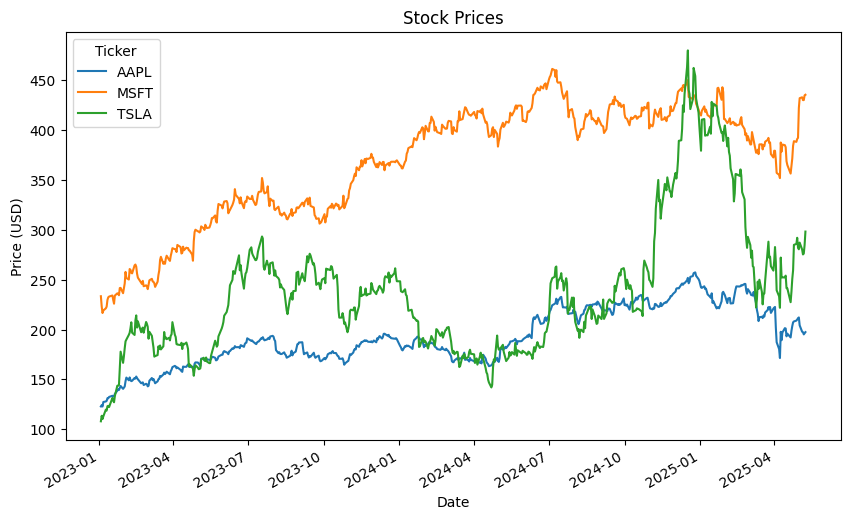

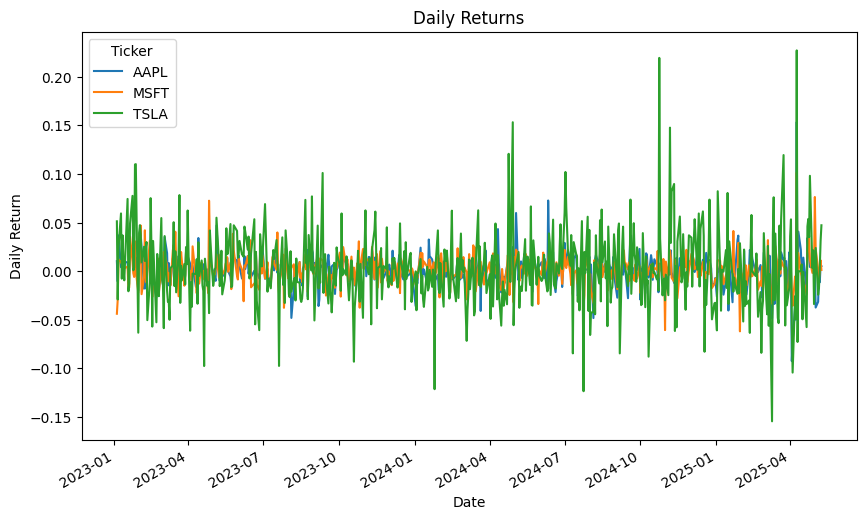

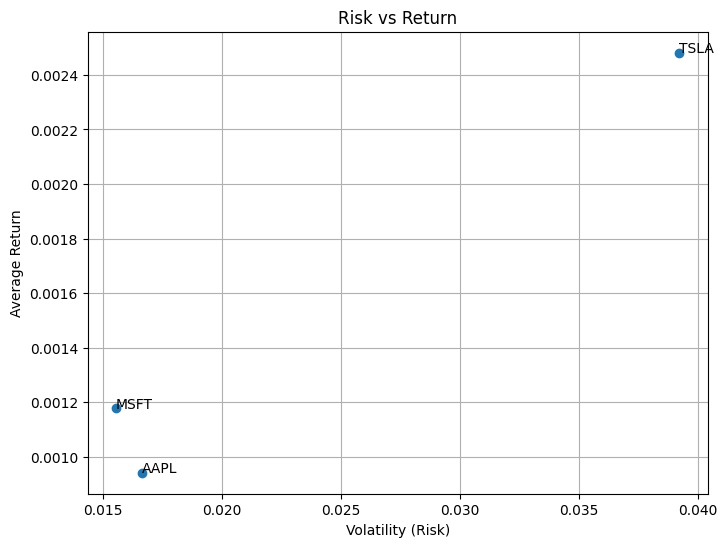

In [17]:

# Plot stock prices
data.plot(figsize=(10, 6), title="Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.show()

# Plot daily returns
returns.plot(figsize=(10, 6), title="Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

# Risk vs Return scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(volatility, avg_returns)

for stock in tickers:
    plt.annotate(stock, (volatility[stock], avg_returns[stock]))

plt.xlabel("Volatility (Risk)")
plt.ylabel("Average Return")
plt.title("Risk vs Return")
plt.grid(True)
plt.show()

Distribution graph

AAPL: 7.64% chance of dropping below -2% in a day


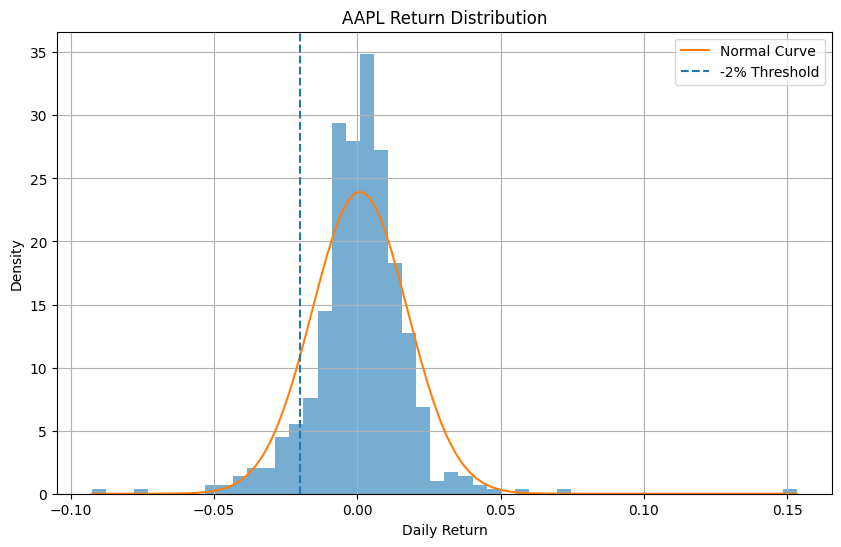

TSLA: 25.30% chance of dropping below -2% in a day


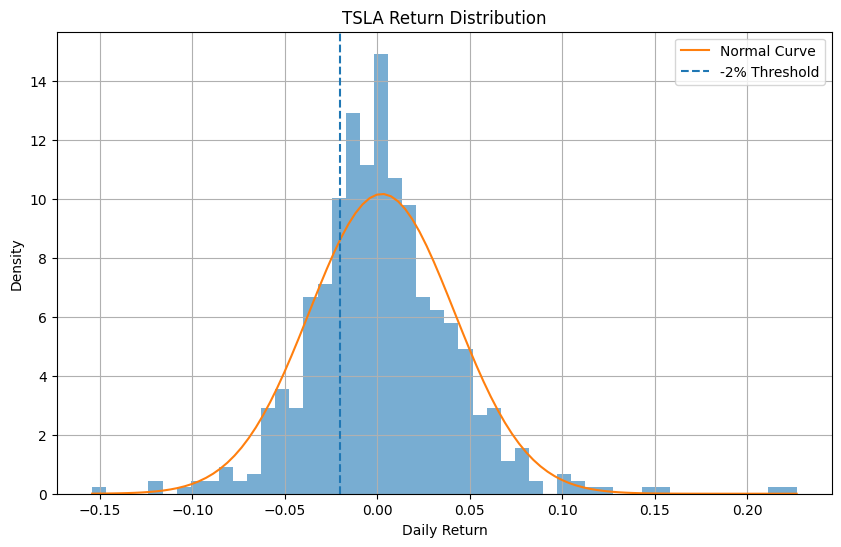

MSFT: 8.15% chance of dropping below -2% in a day


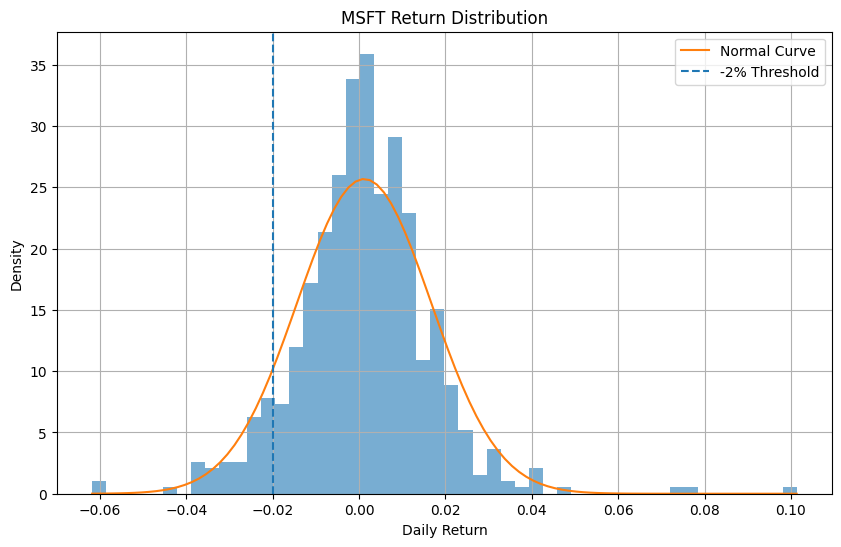

In [18]:
threshold = -0.02   # -2%

for stock in tickers:
    stock_returns = returns[stock].dropna()

    mean = stock_returns.mean()
    std = stock_returns.std()

    if std == 0 or np.isnan(std):
        continue

    # historical probability
    prob_below = (stock_returns < threshold).mean() * 100

    print(f"{stock}: {prob_below:.2f}% chance of dropping below {threshold*100:.0f}% in a day")

    plt.figure(figsize=(10,6))

    plt.hist(stock_returns, bins=50, density=True, alpha=0.6)

    x = np.linspace(stock_returns.min(), stock_returns.max(), 100)
    y = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)

    plt.plot(x, y, label="Normal Curve")

    # vertical line showing threshold
    plt.axvline(threshold, linestyle="--", label=f"{threshold*100:.0f}% Threshold")

    plt.title(f"{stock} Return Distribution")
    plt.xlabel("Daily Return")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

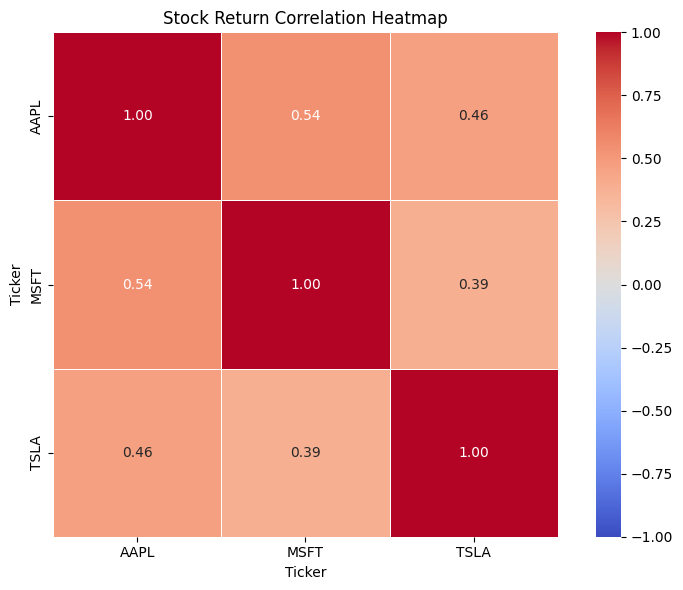

In [19]:
import seaborn as sns

# Compute correlation matrix
corr_matrix = returns.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # show numbers in cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # red = high correlation, blue = low
    vmin=-1, vmax=1,     # fix scale
    square=True,
    linewidths=0.5
)

plt.title("Stock Return Correlation Heatmap")
plt.tight_layout()
plt.show()